## Data Analytics with Python

1. Data Collection: Import (or load) data from various sources: CSV, Excel, JSON, SQL, MongoDB Databases, etc.

In [25]:
# Load the dataset using pandas
import pandas as pd
df = pd.read_csv('heart_disease.csv')

In [26]:
# Retrieve info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      4999 non-null   object 
 1   BMI               4962 non-null   float64
 2   Smoking           4999 non-null   object 
 3   AlcoholDrinking   4999 non-null   object 
 4   Stroke            4996 non-null   object 
 5   PhysicalHealth    4999 non-null   int64  
 6   MentalHealth      4999 non-null   int64  
 7   DiffWalking       4999 non-null   object 
 8   Sex               4997 non-null   object 
 9   AgeCategory       4999 non-null   object 
 10  Race              4964 non-null   object 
 11  Diabetic          4992 non-null   object 
 12  PhysicalActivity  4998 non-null   object 
 13  GenHealth         4999 non-null   object 
 14  SleepTime         4999 non-null   int64  
 15  Asthma            4961 non-null   object 
 16  KidneyDisease     4985 non-null   object 


In [27]:
print(df.isna().sum())

HeartDisease         0
BMI                 37
Smoking              0
AlcoholDrinking      0
Stroke               3
PhysicalHealth       0
MentalHealth         0
DiffWalking          0
Sex                  2
AgeCategory          0
Race                35
Diabetic             7
PhysicalActivity     1
GenHealth            0
SleepTime            0
Asthma              38
KidneyDisease       14
SkinCancer          35
dtype: int64


2.  Data Cleaning (or Data Preparation, Data Preprocessing): Handling missing values, duplicates, outliers, redundant features, inconsistent data formats.

In [28]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns:", num_cols.tolist())
print("Categorical columns:", cat_cols.tolist())

Numerical columns: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical columns: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [29]:
# Impute the categorical column with mode
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Apply MICE algorithm
mice = IterativeImputer(max_iter=10, random_state=0)
df[num_cols] = mice.fit_transform(df[num_cols])
# Simple Imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      4999 non-null   object 
 1   BMI               4999 non-null   float64
 2   Smoking           4999 non-null   object 
 3   AlcoholDrinking   4999 non-null   object 
 4   Stroke            4999 non-null   object 
 5   PhysicalHealth    4999 non-null   float64
 6   MentalHealth      4999 non-null   float64
 7   DiffWalking       4999 non-null   object 
 8   Sex               4999 non-null   object 
 9   AgeCategory       4999 non-null   object 
 10  Race              4999 non-null   object 
 11  Diabetic          4999 non-null   object 
 12  PhysicalActivity  4999 non-null   object 
 13  GenHealth         4999 non-null   object 
 14  SleepTime         4999 non-null   float64
 15  Asthma            4999 non-null   object 
 16  KidneyDisease     4999 non-null   object 


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute quantiles
Q1 = df['BMI'].quantile(0.25)
Q2 = df['BMI'].median()
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR  # Lower bound for outliers
UB = Q3 + 1.5 * IQR  # Upper bound for outliers
# Return the number of outliers BMI
outliers_bmi = df[(df['BMI'] < LB) | (df['BMI'] > UB)]
num_outliers_bmi = len(outliers_bmi)

# Get the max and min without outliers
max_without_outliers = df[(df['BMI'] >= LB) & (df['BMI'] <= UB)]['BMI'].max()
min_without_outliers = df[(df['BMI'] >= LB) & (df['BMI'] <= UB)]['BMI'].min()

Max without outliers: 45.19
Min without outliers: 12.48


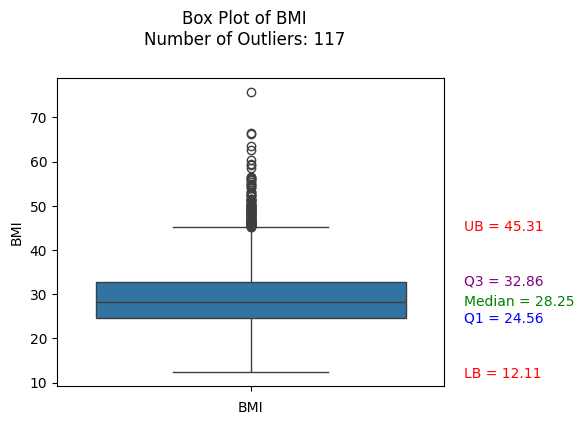

In [32]:
print("Max without outliers:", max_without_outliers)
print("Min without outliers:", min_without_outliers)

plt.figure(figsize=(5, 4))
sns.boxplot(data=df['BMI'])

# Adding text annotations with adjusted positions and different colors
plt.text(0.55, Q1, f'Q1 = {Q1:.2f}', va='center', color='blue')
plt.text(0.55, Q2, f'Median = {Q2:.2f}', va='center', color='green')
plt.text(0.55, Q3, f'Q3 = {Q3:.2f}', va='center', color='purple')
plt.text(0.55, LB, f'LB = {LB:.2f}', va='center', color='red')
plt.text(0.55, UB, f'UB = {UB:.2f}', va='center', color='red')

# Displaying number of outliers below the title
plt.suptitle(f'Box Plot of BMI\nNumber of Outliers: {num_outliers_bmi}',
             y=1.05, fontsize=12)

plt.xlabel('BMI')
plt.ylabel('BMI')
plt.show()

3.  Data Transformation: Normalize values, encode categorical to numerical, derived variables, segmentation numerical variable to groups.

In [33]:
# Apply Encoding on specific group of columns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

binary_cols = [i for i in cat_cols if len(df[i].unique()) == 2] # Binary columns
non_binary_cols = [j for j in cat_cols if j not in binary_cols] # Non-Binary columns
ordinal_cols = pd.Index(non_binary_cols).drop(['Race', 'Diabetic']) # Ordinal columns
non_ordinal_cols = pd.Index(non_binary_cols).drop(['AgeCategory', 'GenHealth']) # Non-ordinal columns

# Label Encoding
label_encoder = LabelEncoder()
for i in binary_cols:
    df[i] = label_encoder.fit_transform(df[i])

# Define ordered categories
age_categories = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
                  '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']

gen_health_categories = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
# Apply Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=[age_categories, gen_health_categories],
                                 handle_unknown='use_encoded_value', unknown_value=-1)

df[['AgeCategory', 'GenHealth']] = ordinal_encoder.fit_transform(df[['AgeCategory', 'GenHealth']])

In [34]:
# One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False)
# Return a matrix
one_hot_data = one_hot_encoder.fit_transform(df[['Race', 'Diabetic']])
# Get feature names
one_hot_cols = one_hot_encoder.get_feature_names_out(['Race', 'Diabetic'])

# Read as dataframe
encoded_df = pd.DataFrame(one_hot_data, columns=one_hot_cols)

# Concatenation
df = pd.concat([df.drop(['Race', 'Diabetic'], axis=1), encoded_df], axis=1)

4. Data Exploring: Summarize data with statistics and visualizations: Mean, Median, Mode, Covariance Matrix, Correlation Matrix

In [35]:
df[num_cols].describe(include='all')

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,4999.000000,4999.00000,4999.000000,4999.000000
mean,29.236384,4.04921,4.284857,7.068414
std,6.587312,8.51139,8.442191,1.573757
min,12.480000,0.00000,0.000000,1.000000
25%,24.560000,0.00000,0.000000,6.000000
50%,28.250000,0.00000,0.000000,7.000000
75%,32.860000,3.00000,4.000000,8.000000
max,75.820000,30.00000,30.000000,20.000000


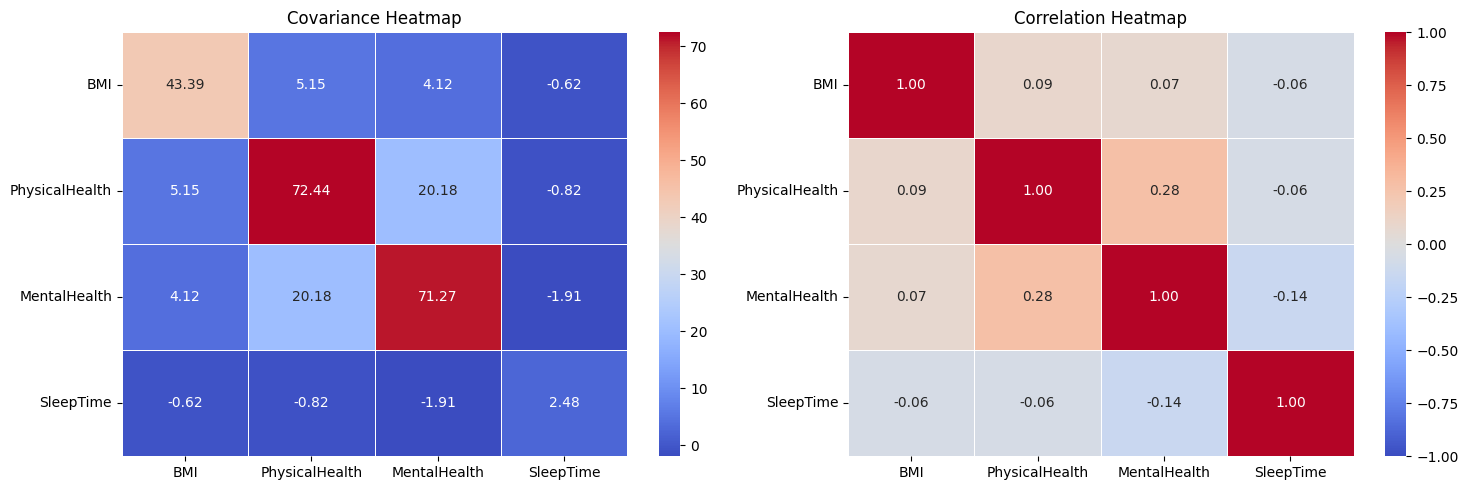

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute covariance and correlation matrices
cov_matrix = df[num_cols].cov()
corr_matrix = df[num_cols].corr()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Covariance heatmap
sns.heatmap(cov_matrix, ax=axes[0], cmap="coolwarm", annot=True,
            fmt=".2f", linewidths=0.5)
axes[0].set_title("Covariance Heatmap")

# Correlation heatmap
sns.heatmap(corr_matrix, ax=axes[1], cmap="coolwarm", annot=True, fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

5. Data Visualization: Represent the data as plots, graphs to identify patterns, trends, and support analysis and decision-making.

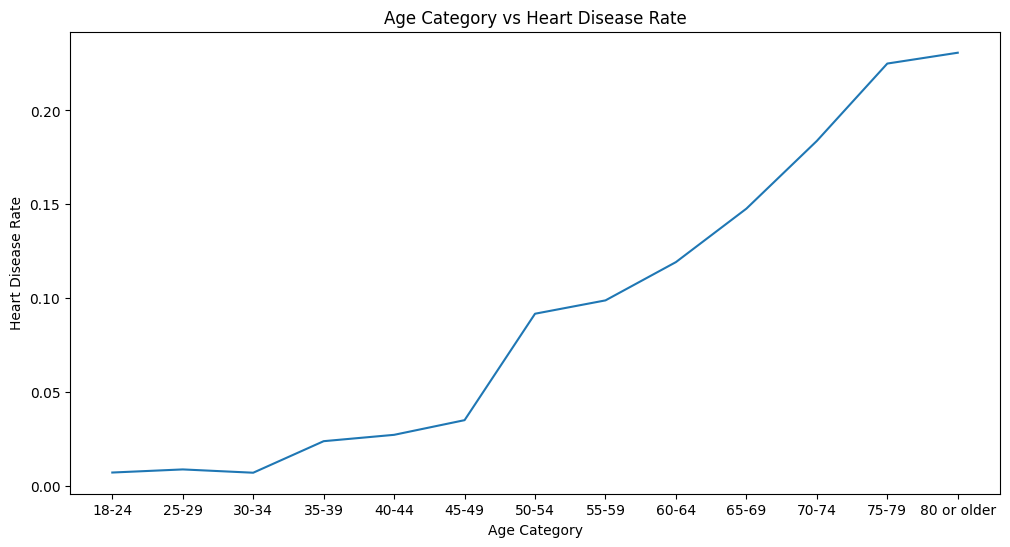

In [37]:
# Group by Age and compute disease rate
age_disease_rate = df.groupby('AgeCategory')['HeartDisease'].mean()
# Convert the Age Category to the original labels
age_disease_rate.index = ordinal_encoder.categories_[0]
# Plot
plt.figure(figsize=(12, 6))
plt.plot(age_disease_rate.index, age_disease_rate.values)
plt.xlabel("Age Category")
plt.ylabel("Heart Disease Rate")
plt.title("Age Category vs Heart Disease Rate")
plt.show()

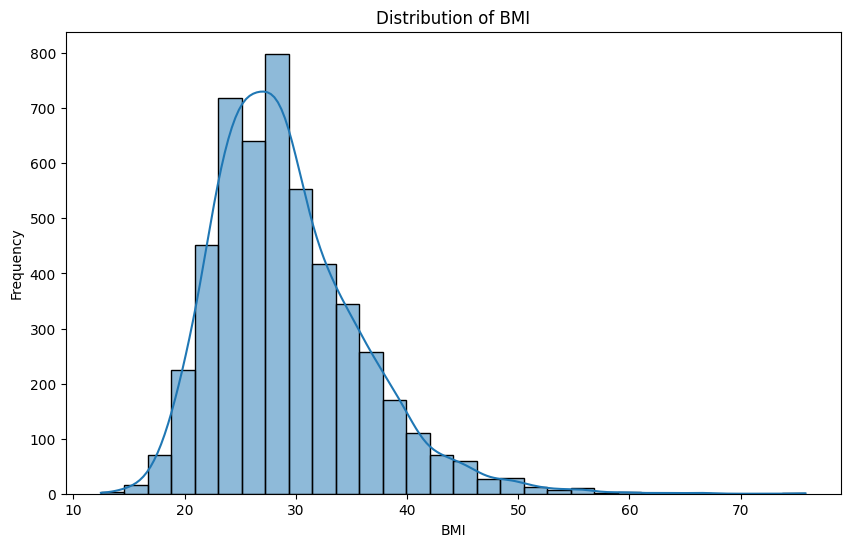

In [38]:
# Show Distribution of BMI
plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

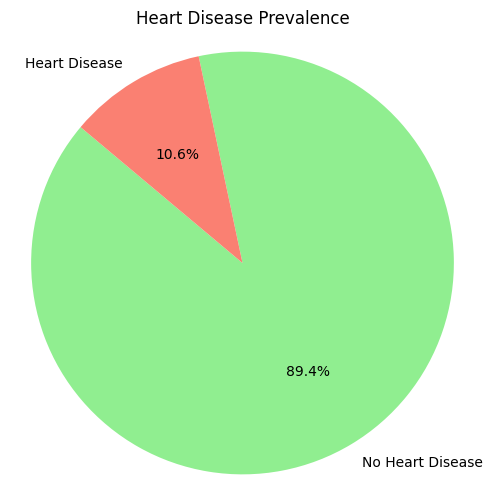

In [39]:
# Draw a pie chart of Heart Disease prevalence
heart_disease_counts = df['HeartDisease'].value_counts()
labels = ['No Heart Disease', 'Heart Disease']
sizes = heart_disease_counts.values
colors = ['lightgreen', 'salmon']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140)
plt.title('Heart Disease Prevalence')
plt.axis('equal')
plt.show()

Model Training

In [40]:
from sklearn.model_selection import train_test_split

target = 'HeartDisease'
features = df.columns.drop(target)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Training Set shape:", train_df.shape)
print("Testing Set shape:", test_df.shape)

Training Set shape: (3999, 26)
Testing Set shape: (1000, 26)


In [41]:
# Normalization using StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/tmp/ipython-input-3695085097.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/tmp/ipython-input-3695085097.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


In [42]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix

def train_evaluate_model(model, name):
    # Fit the model
    model.fit(X_train, y_train)
    # Make prediction
    y_pred = model.predict(X_test)
    # Get probability predictions for ROC curve (probability of the positive class)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    # Model evaluation
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1score = f1_score(y_test, y_pred)
    # Return all the required values
    return conf_matrix, {"Model": name, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1-Score": f1score, "y_pred_proba": y_pred_proba}

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {LogisticRegression(solver='liblinear', random_state=42): 'Logistic Regression',
          DecisionTreeClassifier(criterion='entropy', random_state=42): 'Decision Tree',
             RandomForestClassifier(n_estimators=100, random_state=42): "Random Forest",
             GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                        random_state=42): "Gradient Boosting"}
results = []
cfm_results = []
for key, value in models.items():
    cfm, res = train_evaluate_model(key, value)
    print()
    results.append(res)
    cfm_results.append(cfm)

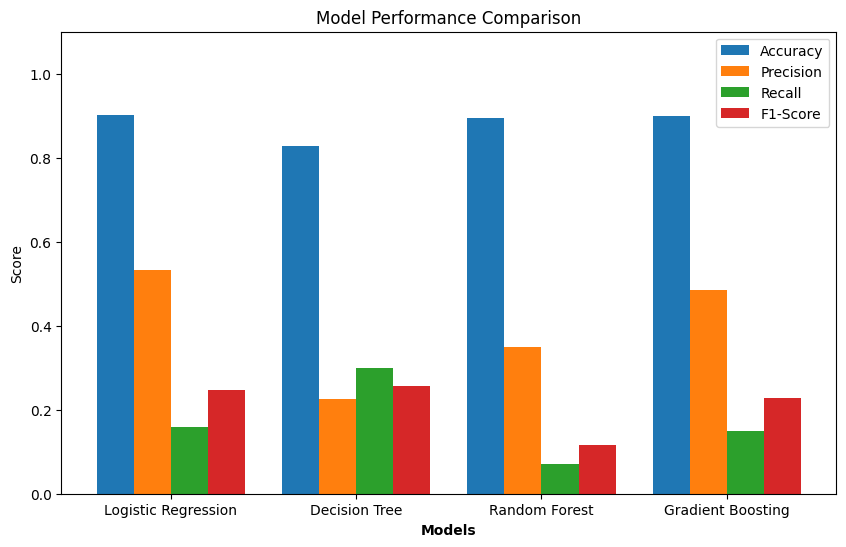

In [44]:
# Plot all four confusion matrices
import matplotlib.pyplot as plt

# Convert the result to dataframe
# Convert to DataFrame
df_results = pd.DataFrame(results)
# Set the metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = df_results['Model']

# Bar width
bar_width = 0.2
r1 = range(len(x))
r2 = [i + bar_width for i in r1]
r3 = [i + bar_width*2 for i in r1]
r4 = [i + bar_width*3 for i in r1]

# Create the plot
plt.figure(figsize=(10,6))
plt.bar(r1, df_results['Accuracy'], width=bar_width, label='Accuracy')
plt.bar(r2, df_results['Precision'], width=bar_width, label='Precision')
plt.bar(r3, df_results['Recall'], width=bar_width, label='Recall')
plt.bar(r4, df_results['F1-Score'], width=bar_width, label='F1-Score')

# Add labels and title
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks([r + 1.5*bar_width for r in range(len(x))], x)
plt.ylim(0, 1.1)
plt.legend()
plt.show()

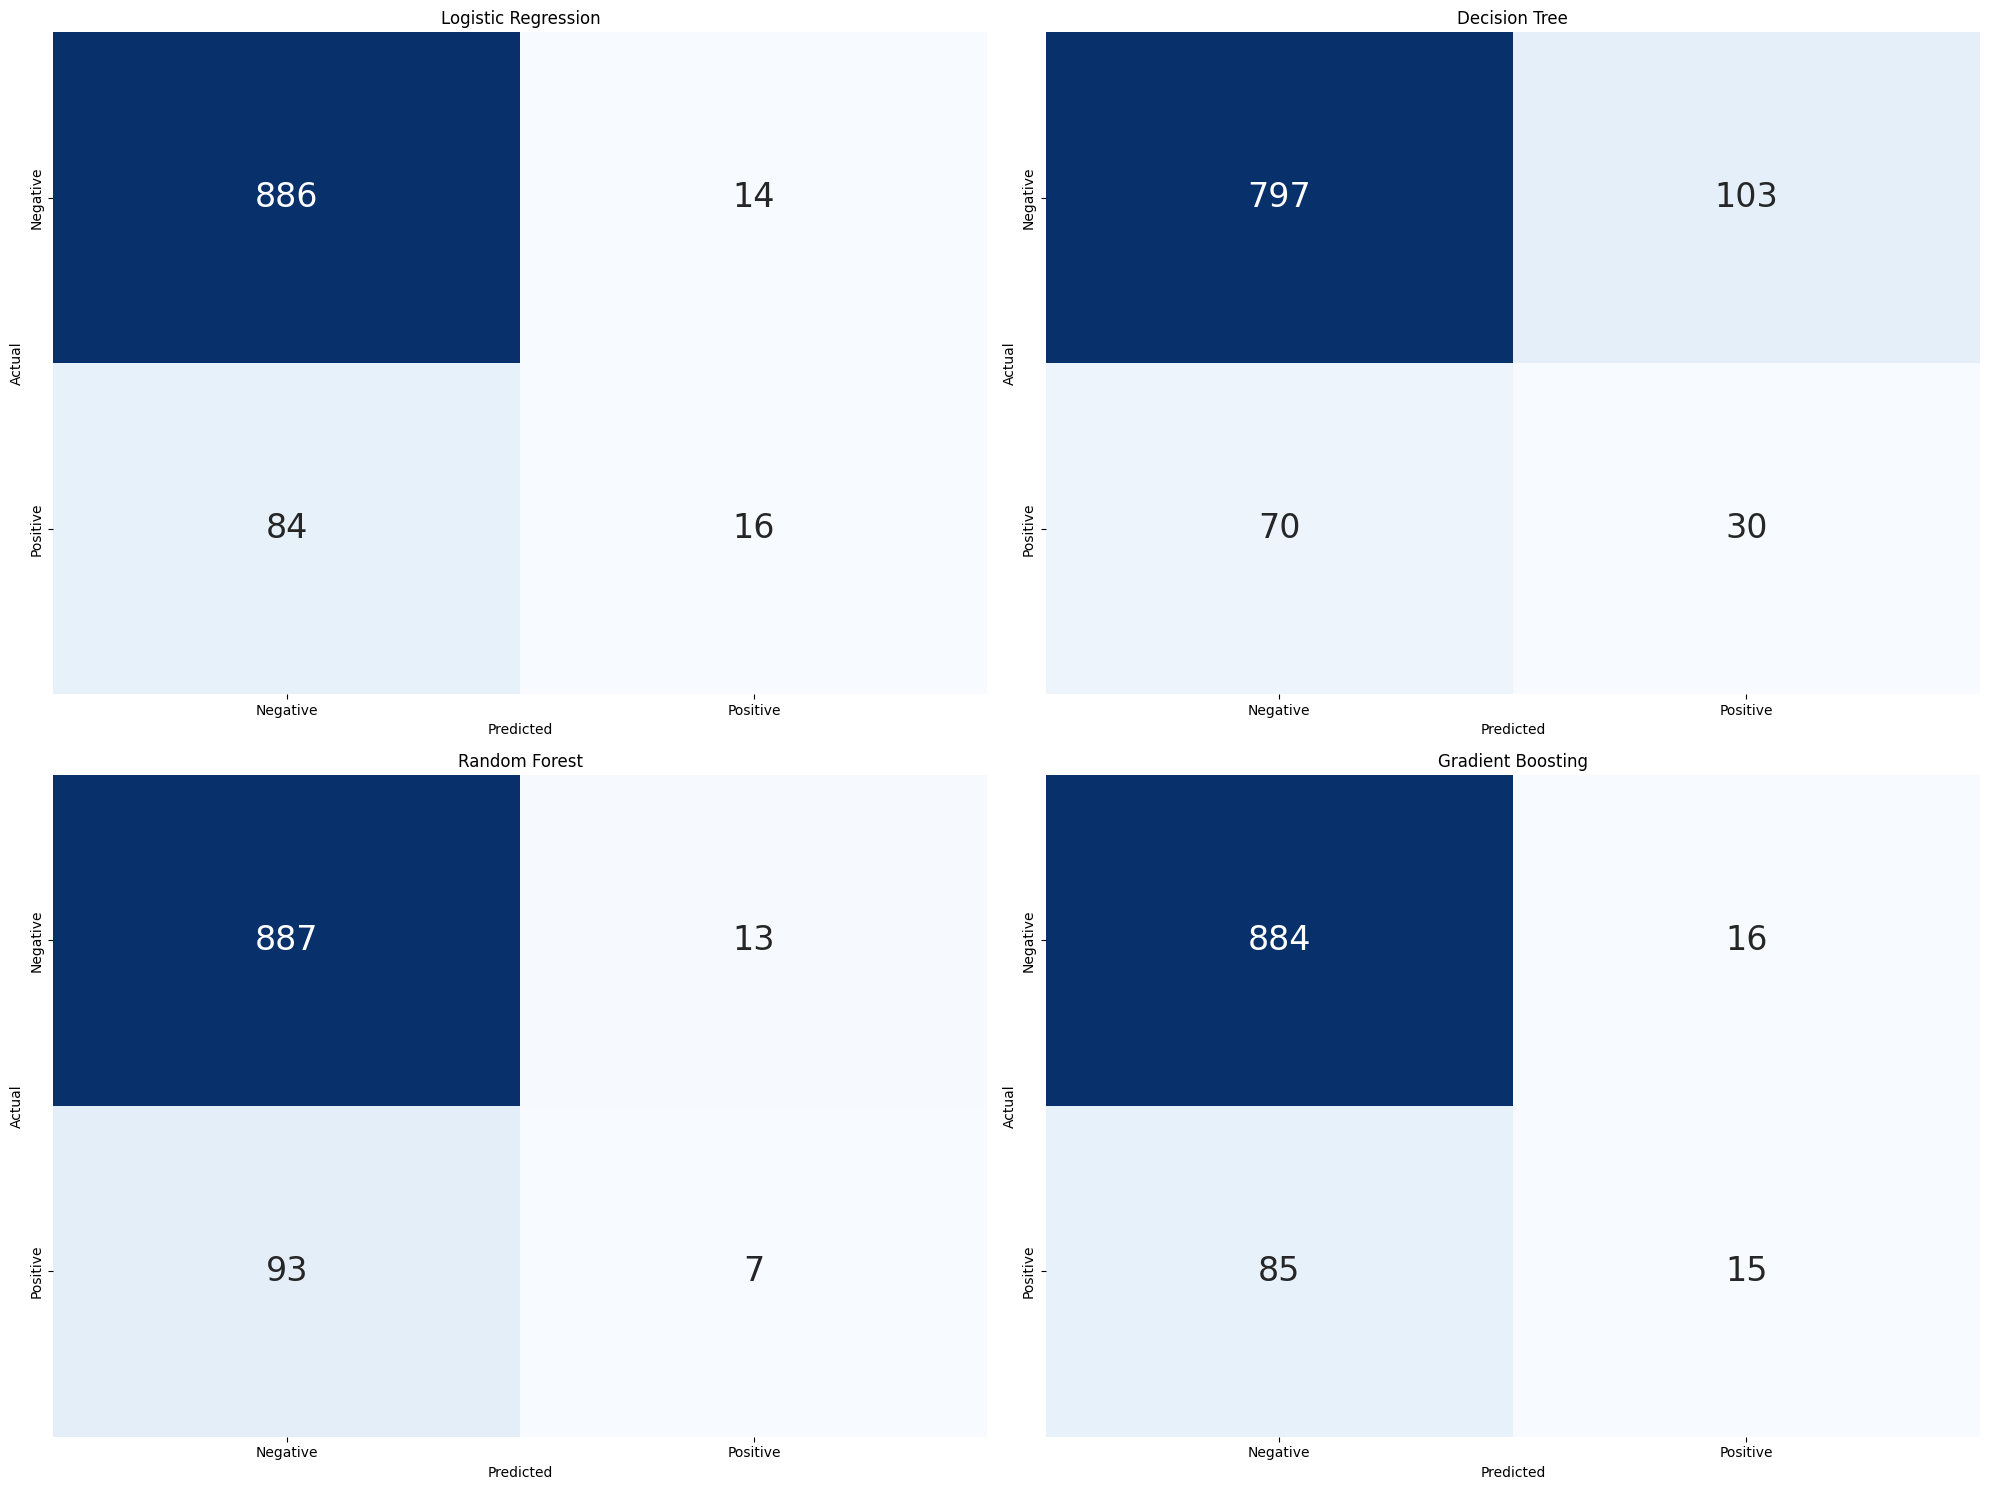

In [45]:
import seaborn as sns

# Define a function to plot confusion matrices
def plot_confusion_matrix(cm, ax, title):
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative',
                                                                   'Positive'],
                annot_kws={"size": 24})
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
# Flatten axes array for easier iteration
axes = axes.flatten()

for c in range(len(cfm_results)):
    plot_confusion_matrix(cfm_results[c], axes[c], results[c].get('Model'))


# Adjust layout and display
plt.tight_layout()
plt.show()

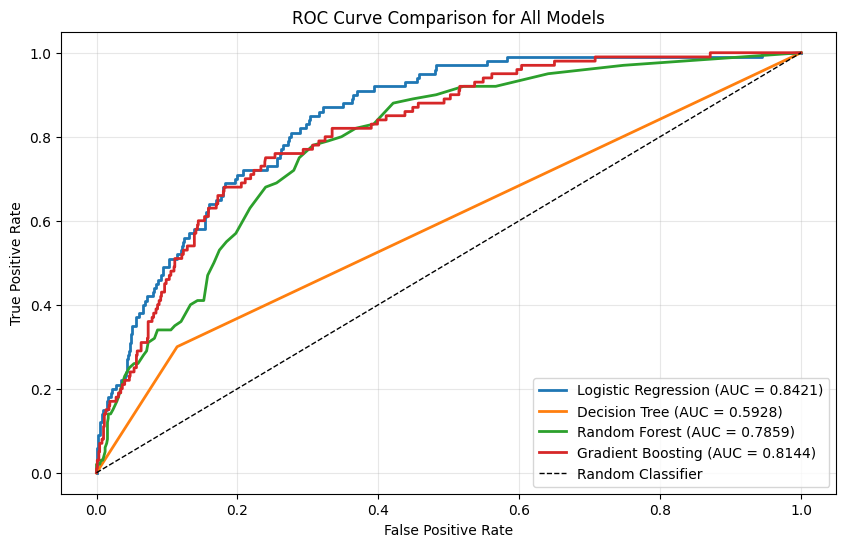

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Iterate through the results to plot ROC curves for all models
for model_result in results:
    model_name = model_result['Model']
    y_pred_proba = model_result['y_pred_proba']

    # Calculate ROC curves and AUC scores
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()